In [1]:
#pip install tensorflow matplotlib numpy pillow


In [2]:
#pip install scipy

In [3]:
#pip show tensorflow


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Load dataset

In [5]:
train_path = "archive/train"
test_path = "archive/test"

# data downloaded from kaggle and unzipped in the same folder as this notebook
# https://www.kaggle.com/datasets/salader/dogsvscats

## Train Model


In [6]:
train_datagen = ImageDataGenerator(             
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [7]:
 #train_datagen = Training Data Generator 
 #It is an object used to:
 #preprocess images
 #augment images
 #prepare batches for training

In [8]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [9]:
model = Sequential()

# Layer 1
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

c:\ProgramData\anaconda3\envs\pawsight\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [13]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20
)

Epoch 1/20


c:\ProgramData\anaconda3\envs\pawsight\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 458s 722ms/step - accuracy: 0.5310 - loss: 0.6966 - val_accuracy: 0.6334 - val_loss: 0.6404
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 363s 578ms/step - accuracy: 0.6629 - loss: 0.6178 - val_accuracy: 0.7484 - val_loss: 0.5053
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 361s 575ms/step - accuracy: 0.7393 - loss: 0.5301 - val_accuracy: 0.7886 - val_loss: 0.4645
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 369s 588ms/step - accuracy: 0.7770 - loss: 0.4791 - val_accuracy: 0.8244 - val_loss: 0.3987
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 357s 568ms/step - accuracy: 0.8026 - loss: 0.4314 - val_accuracy: 0.8244 - val_loss: 0.3878
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 359s 571ms/step - accuracy: 0.8149 - loss: 0.4109 - val_accuracy: 0.8510 - val_loss: 0.3446
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 360s 572ms/step - accuracy: 0.8267 - loss: 0.3857 - val_accuracy: 0.8416 - val_loss: 0.3590
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 362s 576ms/step - accuracy: 0.8262 - loss: 0.38

In [14]:
model.save("cat_dog_model.h5")

Plot Accuracy Graph

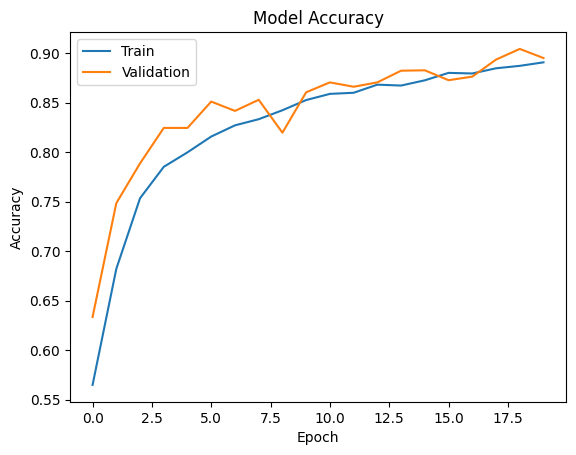

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# Test Model

In [16]:
from tensorflow.keras.preprocessing import image

In [17]:
# save cat or dog image in the same folder and provide the name here

In [18]:
img = image.load_img(
    "sample.jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

In [19]:
prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
[[0.27792004]]


In [20]:
if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Cat
